# 🔍 Notebook 2: Data Validation & Sanity Checks

**Purpose:** Validate experiment data integrity before running any significance test.
Skipping these checks is how bad decisions get made from broken experiments.

### The Three Checks
| Check | What It Catches |
|-------|----------------|
| **Sample Ratio Mismatch (SRM)** | Broken randomization, bot traffic, data pipeline errors |
| **Normality Test** | Determines which statistical test is appropriate |
| **Novelty Effect** | Early inflated lift that decays as users adjust to the change |

> ⚠️ If SRM is detected, **stop the analysis**. Results cannot be trusted.


In [1]:
import sys
sys.path.append('../src')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
warnings.filterwarnings('ignore')
from ab_tests import check_sample_ratio_mismatch, check_normality, check_variance_equality, detect_novelty_effect

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': '#f8f9fa',
    'axes.grid': True, 'grid.alpha': 0.4, 'font.family': 'sans-serif',
    'axes.spines.top': False, 'axes.spines.right': False,
})

# Load all three scenarios
s1 = pd.read_csv('../data/scenario1_ship_it.csv')
s2 = pd.read_csv('../data/scenario2_do_not_ship.csv')
s3 = pd.read_csv('../data/scenario3_inconclusive.csv')

s1_daily = pd.read_csv('../data/scenario1_daily_rates.csv')
s3_daily = pd.read_csv('../data/scenario3_daily_rates.csv')

print("Datasets loaded:")
for name, df in [("Scenario 1 (Ship It)", s1), ("Scenario 2 (Don't Ship)", s2), ("Scenario 3 (Inconclusive)", s3)]:
    print(f"  {name}: {len(df):,} rows, {df['group'].value_counts().to_dict()}")

Datasets loaded:
  Scenario 1 (Ship It): 12,000 rows, {'control': 6000, 'variant': 6000}
  Scenario 2 (Don't Ship): 10,000 rows, {'control': 5000, 'variant': 5000}
  Scenario 3 (Inconclusive): 16,000 rows, {'control': 8000, 'variant': 8000}


---
## Check 1: Sample Ratio Mismatch (SRM)

Were users actually randomized 50/50 into control and variant? A mismatch suggests a broken experiment.

In [2]:
print("SRM CHECK — ALL SCENARIOS")
print("=" * 60)

for name, df in [("Scenario 1", s1), ("Scenario 2", s2), ("Scenario 3", s3)]:
    n_ctrl  = len(df[df['group'] == 'control'])
    n_var   = len(df[df['group'] == 'variant'])
    result  = check_sample_ratio_mismatch(n_ctrl, n_var)
    print(f"\n{name}:")
    print(f"  Control: {result['n_control']:,}  |  Variant: {result['n_variant']:,}")
    print(f"  Actual split: {result['actual_split_control']:.1%}  |  Expected: {result['expected_split']:.1%}")
    print(f"  Chi2: {result['chi2_statistic']}  |  p-value: {result['p_value']}")
    print(f"  {result['interpretation']}")

SRM CHECK — ALL SCENARIOS

Scenario 1:
  Control: 6,000  |  Variant: 6,000
  Actual split: 50.0%  |  Expected: 50.0%
  Chi2: 0.0  |  p-value: 1.0
  ✅ No SRM detected. Sample split looks healthy.

Scenario 2:
  Control: 5,000  |  Variant: 5,000
  Actual split: 50.0%  |  Expected: 50.0%
  Chi2: 0.0  |  p-value: 1.0
  ✅ No SRM detected. Sample split looks healthy.

Scenario 3:
  Control: 8,000  |  Variant: 8,000
  Actual split: 50.0%  |  Expected: 50.0%
  Chi2: 0.0  |  p-value: 1.0
  ✅ No SRM detected. Sample split looks healthy.


---
## Check 2: Normality & Variance Tests

These checks drive the test selection logic in Notebook 3.

In [3]:
print("NORMALITY & VARIANCE CHECKS — SCENARIO 1 (session_duration_sec)")
print("=" * 60)

ctrl_dur = s1[s1['group'] == 'control']['session_duration_sec'].values
var_dur  = s1[s1['group'] == 'variant']['session_duration_sec'].values

norm_c = check_normality(ctrl_dur, 'control')
norm_v = check_normality(var_dur,  'variant')
var_eq = check_variance_equality(ctrl_dur, var_dur)

for r in [norm_c, norm_v]:
    print(f"\n{r['group'].upper()} — {r['test_used']}")
    print(f"  n={r['n']:,}  |  stat={r['statistic']}  |  p={r['p_value']}")
    print(f"  {r['interpretation']}")

print(f"\nLEVENE'S TEST (Equal Variance):")
print(f"  stat={var_eq['levene_statistic']}  |  p={var_eq['p_value']}")
print(f"  {var_eq['interpretation']}")
print(f"  ➜ Recommended test: {var_eq['recommended_test']}")

NORMALITY & VARIANCE CHECKS — SCENARIO 1 (session_duration_sec)

CONTROL — Kolmogorov-Smirnov
  n=6,000  |  stat=0.120202  |  p=0.0
  ⚠️ control: Data is NOT normally distributed (p=0.0000). Consider Mann-Whitney U or bootstrap.

VARIANT — Kolmogorov-Smirnov
  n=6,000  |  stat=0.126394  |  p=0.0
  ⚠️ variant: Data is NOT normally distributed (p=0.0000). Consider Mann-Whitney U or bootstrap.

LEVENE'S TEST (Equal Variance):
  stat=112.758769  |  p=0.0
  ⚠️ Unequal variances detected — use Welch's t-test.
  ➜ Recommended test: Welch's t-test


---
## Check 3: Novelty Effect Detection

Compare early-period lift vs steady-state lift. A spike at launch that fades is a novelty effect — the result is not reliable.

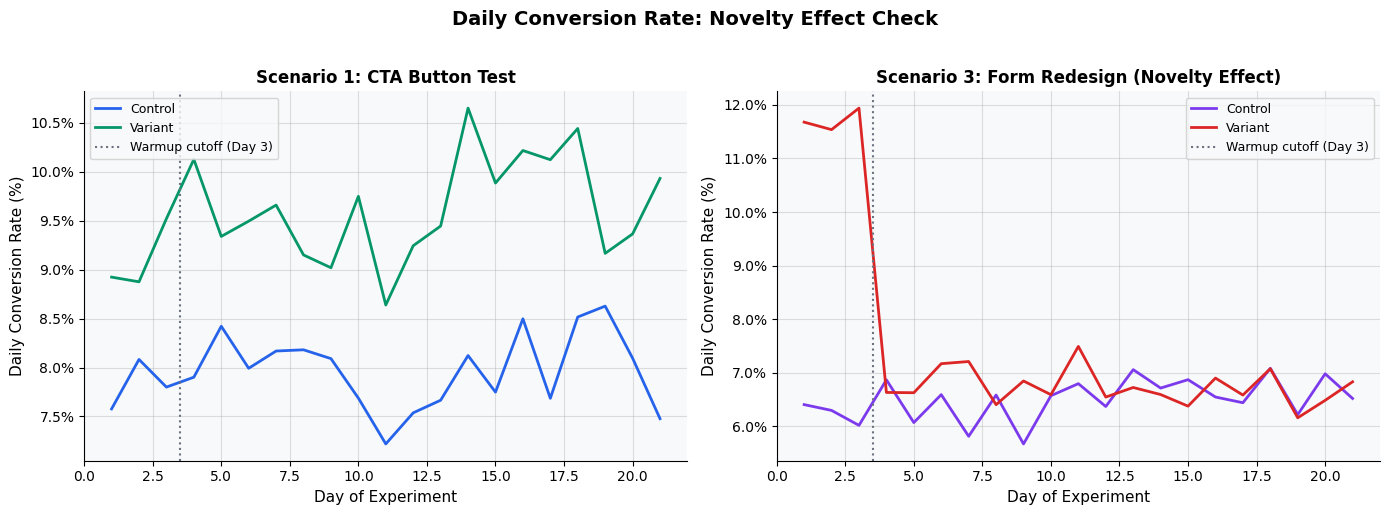


NOVELTY EFFECT ASSESSMENT:
--------------------------------------------------

Scenario 1:
  Early lift: 0.0129
  Steady-state lift: 0.0167
  Lift decay: -29.6%
  ✅ No strong novelty effect. Lift appears stable post-warmup.

Scenario 3:
  Early lift: 0.0548
  Steady-state lift: 0.0019
  Lift decay: 96.5%
  🚨 Novelty effect detected — lift decayed 96.5% after warmup period. Steady-state lift is the more reliable signal.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (daily_df, label, color1, color2) in zip(
    axes,
    [
        (s1_daily, "Scenario 1: CTA Button Test", '#2563eb', '#059669'),
        (s3_daily, "Scenario 3: Form Redesign (Novelty Effect)", '#7c3aed', '#dc2626'),
    ]
):
    days = range(1, len(daily_df) + 1)
    ax.plot(days, daily_df['control_rate'] * 100, label='Control', color=color1, linewidth=2)
    ax.plot(days, daily_df['variant_rate'] * 100, label='Variant', color=color2, linewidth=2)
    ax.axvline(3.5, color='#6b7280', linestyle=':', linewidth=1.5, label='Warmup cutoff (Day 3)')
    ax.set_xlabel('Day of Experiment', fontsize=11)
    ax.set_ylabel('Daily Conversion Rate (%)', fontsize=11)
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.1f%%'))

plt.suptitle('Daily Conversion Rate: Novelty Effect Check', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/02_novelty_effect.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nNOVELTY EFFECT ASSESSMENT:")
print("-" * 50)
for name, daily_df in [("Scenario 1", s1_daily), ("Scenario 3", s3_daily)]:
    result = detect_novelty_effect(daily_df['control_rate'], daily_df['variant_rate'])
    print(f"\n{name}:")
    print(f"  Early lift: {result['early_period_lift']:.4f}")
    print(f"  Steady-state lift: {result['steady_state_lift']:.4f}")
    print(f"  Lift decay: {result['lift_decay_pct']:.1f}%")
    print(f"  {result['interpretation']}")

---
## Validation Summary

| Check | Scenario 1 | Scenario 2 | Scenario 3 |
|-------|-----------|-----------|-----------|
| SRM | ✅ Clean | ✅ Clean | ✅ Clean |
| Normality | ⚠️ Non-normal (log-normal) | ⚠️ Non-normal | ⚠️ Non-normal |
| Novelty Effect | ✅ None | ✅ None | 🚨 Detected |

**Next step → Notebook 03: Significance Testing**
